# 13장 실습 — 파인튜닝: 무엇이 자주 어긋나는가

**대응 이론** 13장 「남의 모델을 내 로봇에 맞추기」 · **실행 등급 B** (CPU 약 8분 / Colab 무료 티어 권장)

파인튜닝은 VLA 를 쓰는 사람 대부분이 실제로 하게 될 유일한 학습이다. 그리고 실패하는 방식이 놀랄 만큼 정형화되어 있다.

이 노트북은 네 가지 함정을 하나씩 재현한다. 셋은 **조용히** 망가진다는 공통점이 있다 — 손실 곡선은 멀쩡하게 내려가고, 학습 지표는 좋아 보이는데, 로봇이 움직이지 않는다.

4장의 미니 VLA 를 소스 로봇에서 사전학습시켜 놓고, 그것을 대상 로봇으로 옮기면서 하나씩 어긋뜨린다.

1. 액션 정규화 통계를 그대로 쓰면
2. 관측 전처리가 어긋나면
3. 전량 미세조정이 지우는 것
4. LoRA — 얼마나 작아도 되는가

In [4]:
%matplotlib inline
import os, sys, math, time, copy
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(os.cpu_count() or 2)
RED, GREY, PINK = "#e32c24", "#c8c8c8", "#f6c9c6"

sys.path.insert(0, os.path.dirname(os.path.abspath("mini_vla.py")))
from mini_vla import (MiniVLA, make_sample, make_dataset, STOI, VOCAB, IMG)
print("torch", torch.__version__)

torch 2.9.1


## 0. 소스 로봇에서 사전학습

우리의 "공개 체크포인트"를 만든다. 4장과 같은 레시피다 — 4096 장면, 900 스텝. 이 셀이 이 노트북에서 가장 오래 걸린다(약 3분).

In [2]:
def fit(m, D, steps, lr, bs=48, wd=.01, seed=0, params=None):
    torch.manual_seed(seed); im, tk, ac = D
    opt = torch.optim.AdamW(
        params if params is not None else m.parameters(), 
        lr, 
        weight_decay=wd
    )
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, steps, pct_start=.15)
    g = torch.Generator().manual_seed(1)
    for i in range(steps):
        idx = torch.randint(0, len(im), (bs,), generator=g)
        loss = F.smooth_l1_loss(m(im[idx], tk[idx]), ac[idx], beta=.05)
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    return m

@torch.no_grad()
def ang(m, D):
    im, tk, ac = D; p = m(im, tk)
    a = torch.atan2(p[:, 1], p[:, 0]); b = torch.atan2(ac[:, 1], ac[:, 0])
    return torch.abs(torch.rad2deg(torch.atan2(torch.sin(a - b), torch.cos(a - b)))).mean().item()

@torch.no_grad()
def mae(m, D):
    im, tk, ac = D; return F.l1_loss(m(im, tk), ac).item()

t0 = time.time()
Dtr = make_dataset(4096, 0); Dte = make_dataset(512, 99)
torch.manual_seed(0); BASE = MiniVLA()
fit(BASE, Dtr, 900, 1.5e-3)
print(f"사전학습 완료  MAE {mae(BASE, Dte):.4f}  각도오차 {ang(BASE, Dte):.1f}°   ({time.time()-t0:.0f}s)")

사전학습 완료  MAE 0.0273  각도오차 4.1°   (40s)


## 1. 액션 정규화 통계를 그대로 쓰면

공개 체크포인트에는 그 모델이 학습한 데이터셋의 **액션 정규화 통계**가 딸려 온다. OpenVLA 는 데이터셋별 1/99 분위수를 쓰고, 파이제로 계열도 비슷한 per-dataset 통계를 들고 다닌다.

대상 로봇은 같은 과제를 하되 **정밀 조작**이라 행동 진폭이 소스의 8% 다. 통계를 새로 계산하지 않고 소스 것을 쓰면 어떻게 되는가.

여기서는 5장의 이산 액션 헤드를 가정한다(256 구간). 학습 없이 **양자화만** 봐도 답이 나온다.


소스 통계 그대로
  축별 사용 구간 수 / 256 : {'x': 21, 'y': 21, 'z': 1, 'roll': 1, 'pitch': 1, 'yaw': 22, 'grip': 2}
  행동 진폭 대비 양자화 오차 : 329.9%

대상 통계 재계산
  축별 사용 구간 수 / 256 : {'x': 32, 'y': 32, 'z': 111, 'roll': 1, 'pitch': 1, 'yaw': 235, 'grip': 2}
  행동 진폭 대비 양자화 오차 : 0.2%


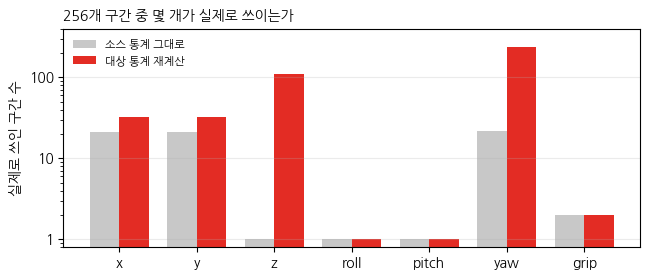

In [5]:
B = 256
FINE = 0.08                                   # 대상 로봇의 행동 진폭 배율
a_src = make_dataset(3000, 0)[2]              # 사전학습 데이터의 액션
a_tgt = make_dataset(1500, 7)[2] * FINE       # 내 로봇의 액션

lo_s, hi_s = torch.quantile(a_src, .01, 0), torch.quantile(a_src, .99, 0)
lo_t, hi_t = torch.quantile(a_tgt, .01, 0), torch.quantile(a_tgt, .99, 0)

def quant(a, lo, hi):
    k = (((a - lo) / (hi - lo + 1e-9)).clamp(0, 1) * (B - 1)).round()
    return k, k / (B - 1) * (hi - lo) + lo

AX = ["x", "y", "z", "roll", "pitch", "yaw", "grip"]
rows = {}
for tag, lo, hi in [("소스 통계 그대로", lo_s, hi_s), ("대상 통계 재계산", lo_t, hi_t)]:
    k, rec = quant(a_tgt, lo, hi)
    used = [len(torch.unique(k[:, j])) for j in range(7)]
    err = (rec - a_tgt).abs().mean(0)
    rows[tag] = used
    print(f"\n{tag}")
    print("  축별 사용 구간 수 / 256 :", dict(zip(AX, used)))
    print(f"  행동 진폭 대비 양자화 오차 : {100*(err/(a_tgt.std(0)+1e-9)).mean():.1f}%")

fig, ax = plt.subplots(figsize=(6.6, 2.9))
x = np.arange(7); w = .38
ax.bar(x - w/2, rows["소스 통계 그대로"], w, color=GREY, label="소스 통계 그대로")
ax.bar(x + w/2, rows["대상 통계 재계산"], w, color=RED, label="대상 통계 재계산")
ax.set_xticks(x); ax.set_xticklabels(AX); ax.set_ylabel("실제로 쓰인 구간 수")
ax.set_yscale("log"); ax.set_ylim(.8, 400)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=.25, axis="y")
ax.set_title("256개 구간 중 몇 개가 실제로 쓰이는가", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 2. 관측 전처리가 어긋나면

두 번째 함정은 이미지 쪽이다. 채널 순서(RGB/BGR), 값 범위([0,1] / [-1,1] / ImageNet 정규화), 리사이즈 방식 — 사전학습 파이프라인과 내 파이프라인이 다르면 어떻게 되는가.

먼저 **영샷**으로 본다. 파인튜닝 전, 전처리만 바꿔서 넣는다.

In [6]:
def bgr(D):  return D[0][:, [2, 1, 0]], D[1], D[2]
def pm1(D):  return D[0] * 2 - 1, D[1], D[2]
def resz(D):
    x = F.interpolate(F.interpolate(D[0], size=24, mode="bilinear", align_corners=False),
                      size=48, mode="bilinear", align_corners=False)
    return x, D[1], D[2]

print("파인튜닝 전 — 전처리만 바꿔서 넣으면")
print(f"  {'원래 전처리':<26}각도 {ang(BASE, Dte):5.1f}°   MAE {mae(BASE, Dte):.4f}")
for tag, f in [("채널 순서 RGB→BGR", bgr), ("값 범위 [0,1]→[-1,1]", pm1), ("해상도 48→24→48", resz)]:
    D = f(Dte)
    print(f"  {tag:<26}각도 {ang(BASE, D):5.1f}°   MAE {mae(BASE, D):.4f}")

파인튜닝 전 — 전처리만 바꿔서 넣으면
  원래 전처리                    각도   4.1°   MAE 0.0273
  채널 순서 RGB→BGR             각도 125.5°   MAE 0.4265
  값 범위 [0,1]→[-1,1]         각도   7.9°   MAE 0.0663
  해상도 48→24→48              각도   3.2°   MAE 0.0250


  원래 전처리                    각도   4.2°   MAE 0.0263


  채널 순서 RGB→BGR             각도 126.9°   MAE 0.4337


  값 범위 [0,1]→[-1,1]         각도   8.9°   MAE 0.0713


  해상도 48→24→48              각도   3.5°   MAE 0.0233


전처리                           30편     100편     300편
----------------------------------------------------
일치 (대조군)                     5.7°     4.8°     3.5°
채널 순서 RGB→BGR               44.2°    23.9°    23.1°
값 범위 [0,1]→[-1,1]            7.5°     4.9°     3.8°
(104s)


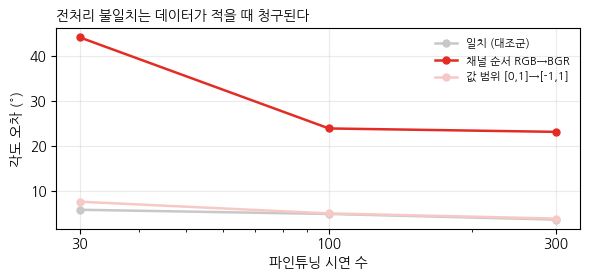

채널 순서 RGB→BGR               40.2°    21.8°    14.2°


값 범위 [0,1]→[-1,1]            8.0°     5.6°     4.4°
(255s)


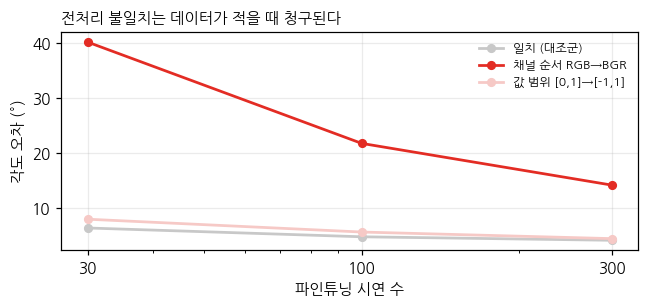

In [7]:
t0 = time.time()
cases = [("일치 (대조군)", lambda X: X), ("채널 순서 RGB→BGR", bgr), ("값 범위 [0,1]→[-1,1]", pm1)]
sizes = [30, 100, 300]
res = {}
print(f"{'전처리':<24}" + "".join(f"{n:>8}편" for n in sizes))
print("-" * 52)
for tag, f in cases:
    row = []
    for n in sizes:
        m = copy.deepcopy(BASE)
        fit(m, f(make_dataset(n, 7)), 250, 3e-4)
        row.append(ang(m, f(Dte)))
    res[tag] = row
    print(f"{tag:<24}" + "".join(f"{v:8.1f}°" for v in row))
print(f"({time.time()-t0:.0f}s)")

fig, ax = plt.subplots(figsize=(6, 2.9))
for (tag, _), c in zip(cases, [GREY, RED, PINK]):
    ax.plot(sizes, res[tag], "o-", color=c, lw=1.8, ms=5, label=tag)
ax.set_xscale("log"); ax.set_xticks(sizes)
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_xlabel("파인튜닝 시연 수"); ax.set_ylabel("각도 오차 (°)")
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=.25)
ax.set_title("전처리 불일치는 데이터가 적을 때 청구된다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 3. 전량 미세조정이 지우는 것

세 번째 함정. 대상 과제가 사전학습 과제의 **일부**일 때 생긴다 — 아주 흔한 경우다. 공개 모델은 수백 가지 과제를 하고 내 로봇은 한 가지만 하면 된다.

빨간 블록만 나오는 시연 200편으로 파인튜닝한다. 그리고 **파란 블록 지시**에서 원래 능력이 살아 있는지 본다.

학습률만 바꿔 가며 세 번 돌린다.

In [8]:
def only(color, n, seed):
    rng = np.random.default_rng(seed); im = []; tk = []; ac = []
    while len(im) < n:
        i, t, a = make_sample(rng)
        if t[3] == STOI[color]: im.append(i); tk.append(t); ac.append(a)
    return (torch.from_numpy(np.stack(im)), torch.from_numpy(np.stack(tk)),
            torch.from_numpy(np.stack(ac)))

Dred_tr = only("red", 200, 7); Dred_te = only("red", 256, 50); Dblue_te = only("blue", 256, 51)
n_par = sum(p.numel() for p in BASE.parameters())
print(f"사전학습 모델        red {ang(BASE, Dred_te):5.1f}°   blue {ang(BASE, Dblue_te):5.1f}°")
print(f"\n{'방식':<20}{'학습 파라미터':>12}{'red(대상)':>11}{'blue(보존)':>12}")
print("-" * 55)
lrs, blues = [], []
for lr in [3e-4, 1e-3, 3e-3]:
    m = copy.deepcopy(BASE); fit(m, Dred_tr, 300, lr)
    b = ang(m, Dblue_te); lrs.append(lr); blues.append(b)
    print(f"{'전량 lr=' + format(lr, 'g'):<20}{n_par:>12,}{ang(m, Dred_te):10.1f}°{b:11.1f}°")

사전학습 모델        red   5.0°   blue   4.1°

방식                       학습 파라미터    red(대상)    blue(보존)
-------------------------------------------------------
전량 lr=0.0003             748,897       3.4°        7.9°
전량 lr=0.001              748,897       5.9°       18.5°
전량 lr=0.003              748,897       5.4°       35.2°


전량 lr=0.0003             748,897       3.0°        6.5°


전량 lr=0.001              748,897       3.7°       16.1°


전량 lr=0.003              748,897       4.9°       68.7°


## 4. LoRA — 얼마나 작아도 되는가

망각을 막는 가장 단순한 방법은 원래 가중치를 **얼리는** 것이다. LoRA 는 각 선형 계층에 저랭크 보정 $BA$ 를 더하고 그것만 학습한다.

<!-- LaTeX: W' = W + \frac{\alpha}{r} B A, \quad B \in \mathbb{R}^{d \times r},\ A \in \mathbb{R}^{r \times k} -->

$B$ 를 0 으로 초기화하므로 학습 시작 시점의 모델은 원본과 **완전히 같다.** 앞 절에서 가장 파괴적이었던 lr=3e-3 을 그대로 쓰고 랭크만 바꾼다.

In [9]:
class LoRA(nn.Module):
    def __init__(s, lin, r, alpha=8):
        super().__init__(); s.lin = lin
        for p in s.lin.parameters(): p.requires_grad = False
        s.A = nn.Parameter(torch.randn(r, lin.in_features) * .01)
        s.B = nn.Parameter(torch.zeros(lin.out_features, r))       # B=0 -> 시작 시 원본과 동일
        s.sc = alpha / r
    def forward(s, x): return s.lin(x) + F.linear(F.linear(x, s.A), s.B) * s.sc

def inject(m, r):
    todo = []
    for mod in m.modules():
        if isinstance(mod, nn.MultiheadAttention): continue        # out_proj 는 건드리지 않는다
        for name, ch in mod.named_children():
            if isinstance(ch, nn.Linear) and ch.in_features >= 32: todo.append((mod, name, ch))
    for mod, name, ch in todo: setattr(mod, name, LoRA(ch, r))
    return m

t0 = time.time()
print(f"{'방식':<20}{'학습 파라미터':>12}{'비율':>8}{'red(대상)':>11}{'blue(보존)':>12}")
print("-" * 63)
m = copy.deepcopy(BASE); fit(m, Dred_tr, 300, 3e-3)
print(f"{'전량 미세조정':<20}{n_par:>12,}{'100%':>8}{ang(m, Dred_te):10.1f}°{ang(m, Dblue_te):11.1f}°")
ranks, reds, blus, pars = [], [], [], []
for r in [1, 2, 4, 8, 16]:
    m = inject(copy.deepcopy(BASE), r)
    for n, p in m.named_parameters(): p.requires_grad = (".A" in n or ".B" in n)
    ps = [p for p in m.parameters() if p.requires_grad]
    fit(m, Dred_tr, 300, 1e-3, params=ps)
    k = sum(p.numel() for p in ps)
    ranks.append(r); reds.append(ang(m, Dred_te)); blus.append(ang(m, Dblue_te)); pars.append(k)
    print(f"{'LoRA r=' + str(r):<20}{k:>12,}{k/n_par:>8.1%}{reds[-1]:10.1f}°{blus[-1]:11.1f}°")
print(f"({time.time()-t0:.0f}s)")

방식                       학습 파라미터      비율    red(대상)    blue(보존)
---------------------------------------------------------------
전량 미세조정                  748,897    100%       5.4°       35.2°
LoRA r=1                   6,145    0.8%       5.4°        4.6°
LoRA r=2                  12,290    1.6%       5.2°        4.7°
LoRA r=4                  24,580    3.3%       5.3°        4.7°
LoRA r=8                  49,160    6.6%       5.2°        4.6°
LoRA r=16                 98,320   13.1%       5.3°        4.7°
(89s)


전량 미세조정                  748,897    100%       4.9°       68.7°


LoRA r=1                   6,145    0.8%       4.4°        5.1°


LoRA r=2                  12,290    1.6%       4.3°        4.9°


LoRA r=4                  24,580    3.3%       4.4°        4.8°


LoRA r=8                  49,160    6.6%       4.4°        4.7°


LoRA r=16                 98,320   13.1%       4.3°        4.8°
(190s)


### 다음 장으로

세 함정 모두 **조용하다**는 점이 공통점이다. 학습 곡선은 내려가고 대상 지표는 좋아 보인다. 다음 장은 이 문제를 정면으로 다룬다 — 무엇을 어떻게 재야 속지 않는가.